In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [4]:
# Load the ticket dataset
df = pd.read_csv('../data/tickets.csv', encoding='latin1')

print("Dataset loaded!")
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded!
Rows:    8,469
Columns: 17


In [5]:

# Look at first 5 rows
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [6]:
# Print all column names
print("Column names:")
for i, col in enumerate(df.columns.tolist(), 1):
    print(f"  {i:2}. {col}")

Column names:
   1. Ticket ID
   2. Customer Name
   3. Customer Email
   4. Customer Age
   5. Customer Gender
   6. Product Purchased
   7. Date of Purchase
   8. Ticket Type
   9. Ticket Subject
  10. Ticket Description
  11. Ticket Status
  12. Resolution
  13. Ticket Priority
  14. Ticket Channel
  15. First Response Time
  16. Time to Resolution
  17. Customer Satisfaction Rating


In [7]:
# Check types and null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [8]:
# Missing values per column
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0])
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values:
Resolution                      5700
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Total missing: 19919


In [9]:
# What ticket categories exist?
print("Ticket Categories:")
print(df['Ticket Type'].value_counts())
print(f"\nTotal categories: {df['Ticket Type'].nunique()}")

Ticket Categories:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Total categories: 5


In [10]:
# What priority levels exist?
print("Priority Levels:")
print(df['Ticket Priority'].value_counts())
print(f"\nTotal priority levels: {df['Ticket Priority'].nunique()}")

Priority Levels:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Total priority levels: 4


In [11]:
# Read a few actual ticket descriptions
print("Sample Ticket Texts:")
print("=" * 60)
for i in range(3):
    print(f"\nTicket {i+1}:")
    print(f"  Category: {df['Ticket Type'].iloc[i]}")
    print(f"  Priority: {df['Ticket Priority'].iloc[i]}")
    print(f"  Text: {df['Ticket Description'].iloc[i][:200]}")
    print("-" * 60)

Sample Ticket Texts:

Ticket 1:
  Category: Technical issue
  Priority: Critical
  Text: I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I'
------------------------------------------------------------

Ticket 2:
  Category: Technical issue
  Priority: Critical
  Text: I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing 
------------------------------------------------------------

Ticket 3:
  Category: Technical issue
  Priority: Low
  Text: I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.

1.8.3 I really I'm using the original cha
-------------------------------------------------------

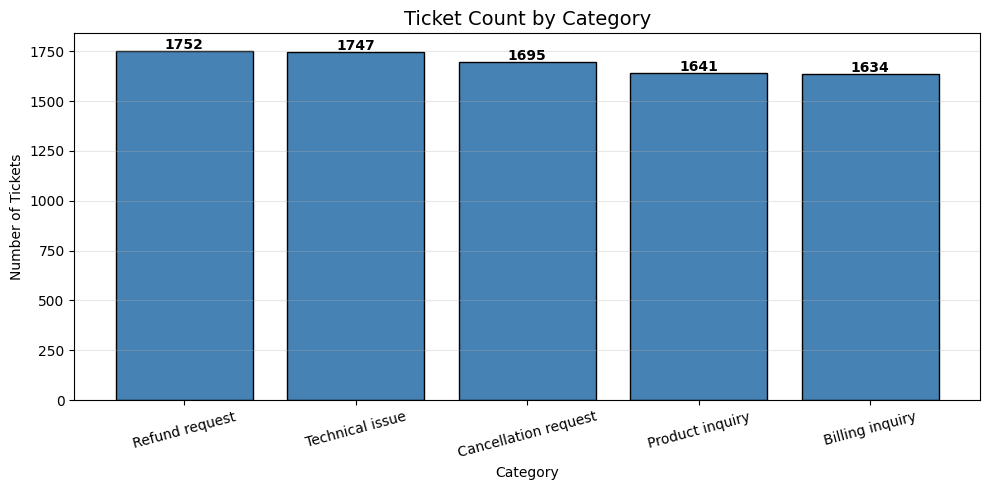

Chart saved!


In [12]:
plt.figure(figsize=(10, 5))
category_counts = df['Ticket Type'].value_counts()

bars = plt.bar(category_counts.index,
               category_counts.values,
               color='steelblue',
               edgecolor='black')

# Add value labels
for bar, val in zip(bars, category_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             str(val),
             ha='center', fontweight='bold')

plt.title('Ticket Count by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../outputs/category_distribution.png')
plt.show()
print("Chart saved!")

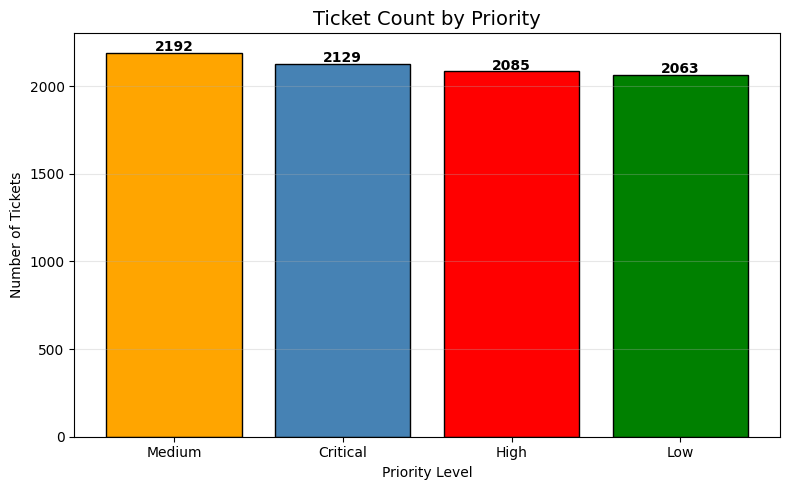

Chart saved!


In [13]:
plt.figure(figsize=(8, 5))
priority_counts = df['Ticket Priority'].value_counts()

colors = {'High': 'red', 'Medium': 'orange', 'Low': 'green'}
bar_colors = [colors.get(p, 'steelblue') 
              for p in priority_counts.index]

bars = plt.bar(priority_counts.index,
               priority_counts.values,
               color=bar_colors,
               edgecolor='black')

for bar, val in zip(bars, priority_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             str(val),
             ha='center', fontweight='bold')

plt.title('Ticket Count by Priority', fontsize=14)
plt.xlabel('Priority Level')
plt.ylabel('Number of Tickets')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../outputs/priority_distribution.png')
plt.show()
print("Chart saved!")

In [14]:
print("=" * 50)
print("     DATASET EXPLORATION SUMMARY")
print("=" * 50)
print(f"\nTotal tickets:       {len(df):,}")
print(f"Total columns:       {df.shape[1]}")
print(f"Missing values:      {df.isnull().sum().sum()}")
print(f"\nCategories found:")
for cat, count in df['Ticket Type'].value_counts().items():
    pct = count/len(df)*100
    print(f"  {cat:<25} {count:>5} ({pct:.1f}%)")
print(f"\nPriority levels found:")
for pri, count in df['Ticket Priority'].value_counts().items():
    pct = count/len(df)*100
    print(f"  {pri:<25} {count:>5} ({pct:.1f}%)")
print("=" * 50)
print("Ready for Step 2 — Text Cleaning!")

     DATASET EXPLORATION SUMMARY

Total tickets:       8,469
Total columns:       17
Missing values:      19919

Categories found:
  Refund request             1752 (20.7%)
  Technical issue            1747 (20.6%)
  Cancellation request       1695 (20.0%)
  Product inquiry            1641 (19.4%)
  Billing inquiry            1634 (19.3%)

Priority levels found:
  Medium                     2192 (25.9%)
  Critical                   2129 (25.1%)
  High                       2085 (24.6%)
  Low                        2063 (24.4%)
Ready for Step 2 — Text Cleaning!


In [15]:
import nltk

# Download required NLTK packages
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("NLTK data downloaded!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sayak\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sayak\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sayak\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sayak\AppData\Roaming\nltk_data...


NLTK data downloaded!


In [16]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Preview stopwords
print(f"Total stopwords: {len(stop_words)}")
print(f"Sample stopwords: {list(stop_words)[:15]}")

Total stopwords: 198
Sample stopwords: ['with', 'same', 'couldn', 'him', 'those', 'whom', 'yourself', 'yourselves', 'they', "you'd", 'your', 'down', 'itself', "wasn't", 'in']


In [17]:
def clean_text(text):
    """
    Cleans a single ticket text through multiple steps:
    1. Handle missing/null values
    2. Lowercase everything
    3. Remove URLs
    4. Remove email addresses
    5. Remove punctuation and special characters
    6. Remove numbers
    7. Remove extra whitespace
    8. Remove stopwords
    9. Lemmatize words
    """
    
    # Step 1: Handle null/missing
    if pd.isna(text) or text == '':
        return ''
    
    # Step 2: Lowercase
    text = text.lower()
    
    # Step 3: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Step 4: Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Step 5: Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Step 6: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 7: Tokenize (split into words)
    words = text.split()
    
    # Step 8: Remove stopwords and short words
    words = [w for w in words 
             if w not in stop_words and len(w) > 2]
    
    # Step 9: Lemmatize (e.g. "running" → "run")
    words = [lemmatizer.lemmatize(w) for w in words]
    
    return ' '.join(words)

print("Text cleaning function defined!")

# Test it on a sample
sample = "I CANNOT login!! My account is NOT working... please HELP!!!"
print(f"\nOriginal: {sample}")
print(f"Cleaned:  {clean_text(sample)}")

Text cleaning function defined!

Original: I CANNOT login!! My account is NOT working... please HELP!!!
Cleaned:  cannot login account working please help


In [18]:
print("Cleaning ticket descriptions...")
print("This may take 30-60 seconds...")

# Apply cleaning to all tickets
df['Cleaned_Description'] = df['Ticket Description'].apply(clean_text)

print("Done!")
print(f"\nSample before and after cleaning:")
print("=" * 60)
for i in range(3):
    print(f"\nTicket {i+1}:")
    print(f"  BEFORE: {df['Ticket Description'].iloc[i][:150]}")
    print(f"  AFTER:  {df['Cleaned_Description'].iloc[i][:150]}")
    print("-" * 60)

Cleaning ticket descriptions...
This may take 30-60 seconds...
Done!

Sample before and after cleaning:

Ticket 1:
  BEFORE: I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website ad
  AFTER:  issue productpurchased please assist billing zip code appreciate requested website address please double check email address ive tried troubleshooting
------------------------------------------------------------

Ticket 2:
  BEFORE: I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_pu
  AFTER:  issue productpurchased please assist need change existing product issue productpurchased please assist issue facing intermittent sometimes work fine t
------------------------------------------------------------

Ticket 3:
  BEFORE: I'm facing a problem with my {product_purchased}. The {product_purchased} is not turnin

In [19]:
# Clean subject line too
df['Cleaned_Subject'] = df['Ticket Subject'].apply(clean_text)

print("Subject lines cleaned!")
print("\nSample subjects:")
for i in range(5):
    print(f"  Original: {df['Ticket Subject'].iloc[i]}")
    print(f"  Cleaned:  {df['Cleaned_Subject'].iloc[i]}")
    print()

Subject lines cleaned!

Sample subjects:
  Original: Product setup
  Cleaned:  product setup

  Original: Peripheral compatibility
  Cleaned:  peripheral compatibility

  Original: Network problem
  Cleaned:  network problem

  Original: Account access
  Cleaned:  account access

  Original: Data loss
  Cleaned:  data loss



In [20]:
# Combine subject + description into one text field
# Subject gives context, description gives detail
df['Combined_Text'] = (df['Cleaned_Subject'] + 
                       ' ' + 
                       df['Cleaned_Description'])

print("Combined text created!")
print(f"\nSample combined text:")
print("=" * 60)
for i in range(2):
    print(f"\nTicket {i+1}:")
    print(f"  Category: {df['Ticket Type'].iloc[i]}")
    print(f"  Priority: {df['Ticket Priority'].iloc[i]}")
    print(f"  Combined: {df['Combined_Text'].iloc[i][:200]}")
    print("-" * 60)

Combined text created!

Sample combined text:

Ticket 1:
  Category: Technical issue
  Priority: Critical
  Combined: product setup issue productpurchased please assist billing zip code appreciate requested website address please double check email address ive tried troubleshooting step mentioned user manual issue pe
------------------------------------------------------------

Ticket 2:
  Category: Technical issue
  Priority: Critical
  Combined: peripheral compatibility issue productpurchased please assist need change existing product issue productpurchased please assist issue facing intermittent sometimes work fine time act unexpectedly
------------------------------------------------------------


In [21]:
from sklearn.preprocessing import LabelEncoder

# Encode Ticket Type (category)
category_encoder = LabelEncoder()
df['Category_Label'] = category_encoder.fit_transform(
    df['Ticket Type']
)

# Encode Ticket Priority
priority_encoder = LabelEncoder()
df['Priority_Label'] = priority_encoder.fit_transform(
    df['Ticket Priority']
)

print("Labels encoded!")
print("\nCategory encoding:")
for name, code in zip(category_encoder.classes_,
                      range(len(category_encoder.classes_))):
    print(f"  {code} → {name}")

print("\nPriority encoding:")
for name, code in zip(priority_encoder.classes_,
                      range(len(priority_encoder.classes_))):
    print(f"  {code} → {name}")

Labels encoded!

Category encoding:
  0 → Billing inquiry
  1 → Cancellation request
  2 → Product inquiry
  3 → Refund request
  4 → Technical issue

Priority encoding:
  0 → Critical
  1 → High
  2 → Low
  3 → Medium


Text length statistics:
  Average words per ticket: 25
  Shortest ticket:          13 words
  Longest ticket:           47 words


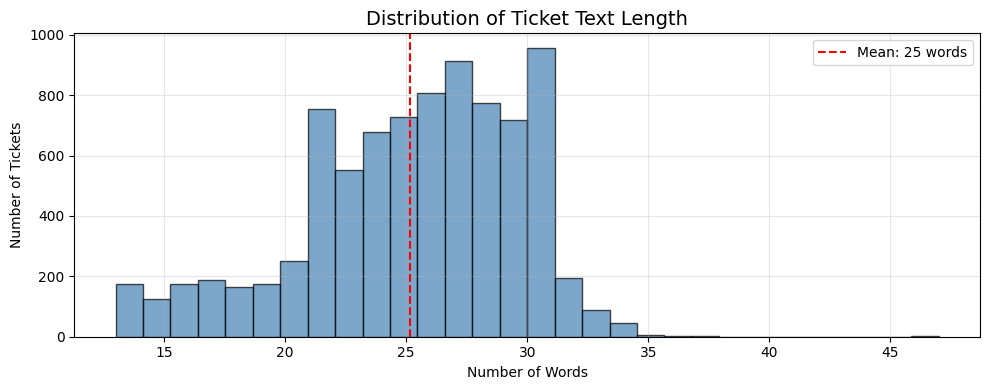

Chart saved!


In [22]:
# How long are the cleaned texts?
df['Text_Length'] = df['Combined_Text'].apply(
    lambda x: len(x.split())
)

print("Text length statistics:")
print(f"  Average words per ticket: "
      f"{df['Text_Length'].mean():.0f}")
print(f"  Shortest ticket:          "
      f"{df['Text_Length'].min()} words")
print(f"  Longest ticket:           "
      f"{df['Text_Length'].max()} words")

# Plot distribution
plt.figure(figsize=(10, 4))
plt.hist(df['Text_Length'], bins=30,
         color='steelblue', edgecolor='black',
         alpha=0.7)
plt.title('Distribution of Ticket Text Length',
          fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Number of Tickets')
plt.axvline(x=df['Text_Length'].mean(),
            color='red', linestyle='--',
            label=f"Mean: {df['Text_Length'].mean():.0f} words")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/text_length_distribution.png')
plt.show()
print("Chart saved!")

In [23]:
# Check for empty texts after cleaning
empty_texts = (df['Combined_Text'].str.strip() == '').sum()
print(f"Empty texts after cleaning: {empty_texts}")

# Remove empty texts if any
if empty_texts > 0:
    df = df[df['Combined_Text'].str.strip() != '']
    df = df.reset_index(drop=True)
    print(f"Removed {empty_texts} empty rows")
    print(f"Remaining tickets: {len(df):,}")
else:
    print("No empty texts — all tickets have content!")
    print(f"Total tickets: {len(df):,}")

Empty texts after cleaning: 0
No empty texts — all tickets have content!
Total tickets: 8,469


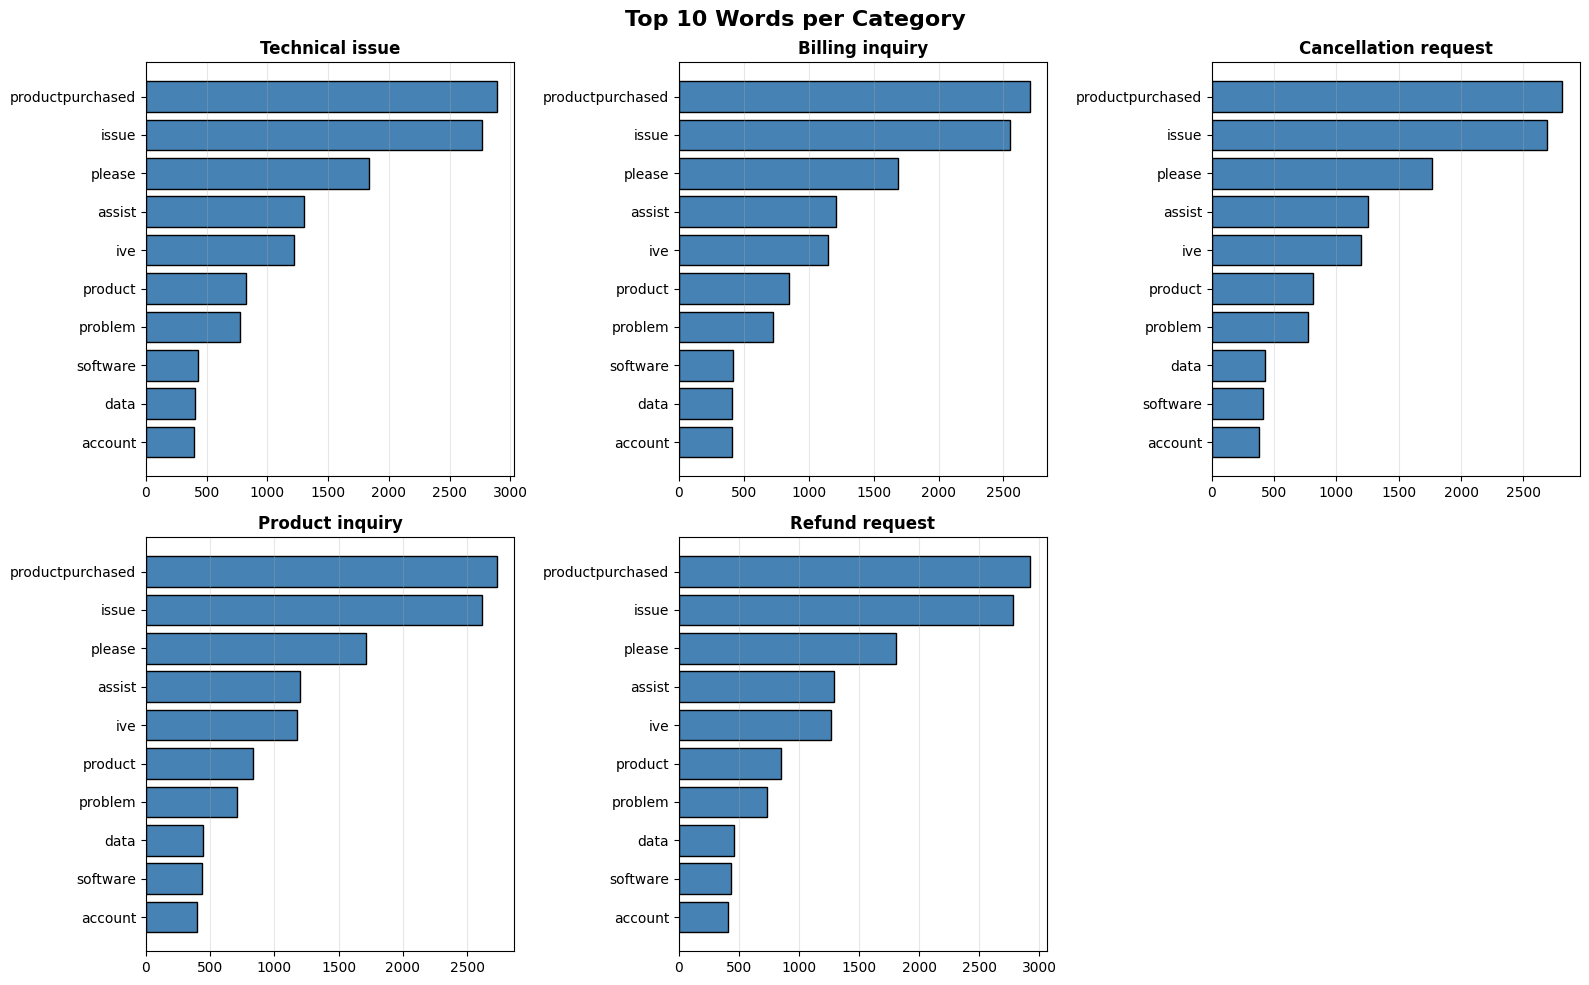

Word frequency chart saved!


In [24]:
from collections import Counter

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

categories = df['Ticket Type'].unique()

for idx, category in enumerate(categories):
    # Get all words for this category
    cat_texts = df[df['Ticket Type'] == category][
        'Combined_Text'
    ].str.cat(sep=' ')
    
    # Count word frequencies
    word_counts = Counter(cat_texts.split())
    top_words   = dict(word_counts.most_common(10))
    
    # Plot
    axes[idx].barh(list(top_words.keys()),
                   list(top_words.values()),
                   color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{category}', fontweight='bold')
    axes[idx].invert_yaxis()
    axes[idx].grid(True, alpha=0.3, axis='x')

# Hide the 6th subplot (we only have 5 categories)
axes[5].set_visible(False)

plt.suptitle('Top 10 Words per Category',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/top_words_per_category.png',
            dpi=150)
plt.show()
print("Word frequency chart saved!")

In [25]:
print("=" * 55)
print("       TEXT CLEANING SUMMARY")
print("=" * 55)
print(f"\nTotal tickets cleaned:    {len(df):,}")
print(f"Text column used:         Ticket Description")
print(f"                        + Ticket Subject")
print(f"Combined into:            Combined_Text")
print(f"\nCleaning steps applied:")
print(f"  ✓ Lowercasing")
print(f"  ✓ URL removal")
print(f"  ✓ Email removal")
print(f"  ✓ Punctuation removal")
print(f"  ✓ Number removal")
print(f"  ✓ Stopword removal")
print(f"  ✓ Lemmatization")
print(f"\nLabels encoded:")
print(f"  ✓ Ticket Type   → Category_Label (0-4)")
print(f"  ✓ Ticket Priority → Priority_Label (0-3)")
print(f"\nAvg words per ticket:     "
      f"{df['Text_Length'].mean():.0f}")
print("=" * 55)
print("Ready for Step 3 — Feature Extraction!")

       TEXT CLEANING SUMMARY

Total tickets cleaned:    8,469
Text column used:         Ticket Description
                        + Ticket Subject
Combined into:            Combined_Text

Cleaning steps applied:
  ✓ Lowercasing
  ✓ URL removal
  ✓ Email removal
  ✓ Punctuation removal
  ✓ Number removal
  ✓ Stopword removal
  ✓ Lemmatization

Labels encoded:
  ✓ Ticket Type   → Category_Label (0-4)
  ✓ Ticket Priority → Priority_Label (0-3)

Avg words per ticket:     25
Ready for Step 3 — Feature Extraction!


In [26]:
from sklearn.feature_extraction.text import (
    TfidfVectorizer, CountVectorizer
)
from sklearn.model_selection import train_test_split

print("Feature extraction tools imported!")

Feature extraction tools imported!


In [27]:
# Split BEFORE feature extraction to prevent data leakage
# Data leakage = model accidentally sees test data during training

X = df['Combined_Text']          # input text
y_category = df['Category_Label'] # target 1: category
y_priority = df['Priority_Label'] # target 2: priority

# 80% training, 20% testing
X_train, X_test, \
y_cat_train, y_cat_test, \
y_pri_train, y_pri_test = train_test_split(
    X,
    y_category,
    y_priority,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_category  # ensures balanced split
)

print("Data split complete!")
print(f"\nTraining samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}")
print(f"\nCategory distribution in training set:")
for label, count in pd.Series(y_cat_train).value_counts().items():
    name = category_encoder.classes_[label]
    pct  = count/len(y_cat_train)*100
    print(f"  {name:<25} {count:>5} ({pct:.1f}%)")

Data split complete!

Training samples: 6,775
Testing samples:  1,694

Category distribution in training set:
  Refund request             1401 (20.7%)
  Technical issue            1398 (20.6%)
  Cancellation request       1356 (20.0%)
  Product inquiry            1313 (19.4%)
  Billing inquiry            1307 (19.3%)


In [28]:
# Build TF-IDF vectorizer
# max_features = only keep top 5000 most important words
# ngram_range  = (1,2) means single words AND word pairs
#                "not working" is more meaningful than "not" + "working"
# min_df       = word must appear in at least 2 tickets
# max_df       = ignore words in more than 95% of tickets

tfidf = TfidfVectorizer(
    max_features = 5000,
    ngram_range  = (1, 2),
    min_df       = 2,
    max_df       = 0.95,
    sublinear_tf = True   # reduces impact of very frequent words
)

# Fit on training data ONLY, then transform both
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF vectorization complete!")
print(f"\nTraining matrix shape: {X_train_tfidf.shape}")
print(f"Testing matrix shape:  {X_test_tfidf.shape}")
print(f"\nThis means:")
print(f"  {X_train_tfidf.shape[0]:,} tickets")
print(f"  {X_train_tfidf.shape[1]:,} unique word features")

TF-IDF vectorization complete!

Training matrix shape: (6775, 5000)
Testing matrix shape:  (1694, 5000)

This means:
  6,775 tickets
  5,000 unique word features


In [29]:
# See what words TF-IDF considers most important
feature_names = tfidf.get_feature_names_out()

print(f"Total features (words/phrases): {len(feature_names):,}")
print(f"\nFirst 20 features:")
print(list(feature_names[:20]))
print(f"\nLast 20 features:")
print(list(feature_names[-20:]))

# Find top TF-IDF words for each category
print("\n" + "="*55)
print("Top TF-IDF words per category:")
print("="*55)

# Convert sparse matrix to array for analysis
X_train_array = X_train_tfidf.toarray()

for label in range(len(category_encoder.classes_)):
    category_name = category_encoder.classes_[label]
    
    # Get indices of tickets in this category
    cat_indices = [i for i, l in enumerate(y_cat_train) 
                   if l == label]
    
    # Average TF-IDF score for each word in this category
    cat_tfidf_avg = X_train_array[cat_indices].mean(axis=0)
    
    # Top 8 words
    top_indices = cat_tfidf_avg.argsort()[-8:][::-1]
    top_words   = [feature_names[i] for i in top_indices]
    
    print(f"\n  {category_name}:")
    print(f"    {', '.join(top_words)}")

Total features (words/phrases): 5,000

First 20 features:
['ability', 'able', 'able add', 'able find', 'able get', 'able help', 'able ive', 'able make', 'able obtain', 'able play', 'able purchase', 'able receive', 'able see', 'able sell', 'able ship', 'able take', 'able use', 'able view', 'absolutely', 'accept']

Last 20 features:
['youre right', 'youre running', 'youre selling', 'youre still', 'youre sure', 'youre thinking', 'youre trying', 'youre using', 'youre way', 'yournet', 'youtube', 'youve', 'youve already', 'youve asked', 'youve bought', 'youve got', 'youve purchased', 'youve received', 'youve seen', 'youve taken']

Top TF-IDF words per category:

  Billing inquiry:
    issue, please, assist, please assist, issue productpurchased, productpurchased please, ive, product

  Cancellation request:
    issue, please, assist, please assist, productpurchased please, issue productpurchased, ive, product

  Product inquiry:
    issue, please, assist, please assist, issue productpurchase

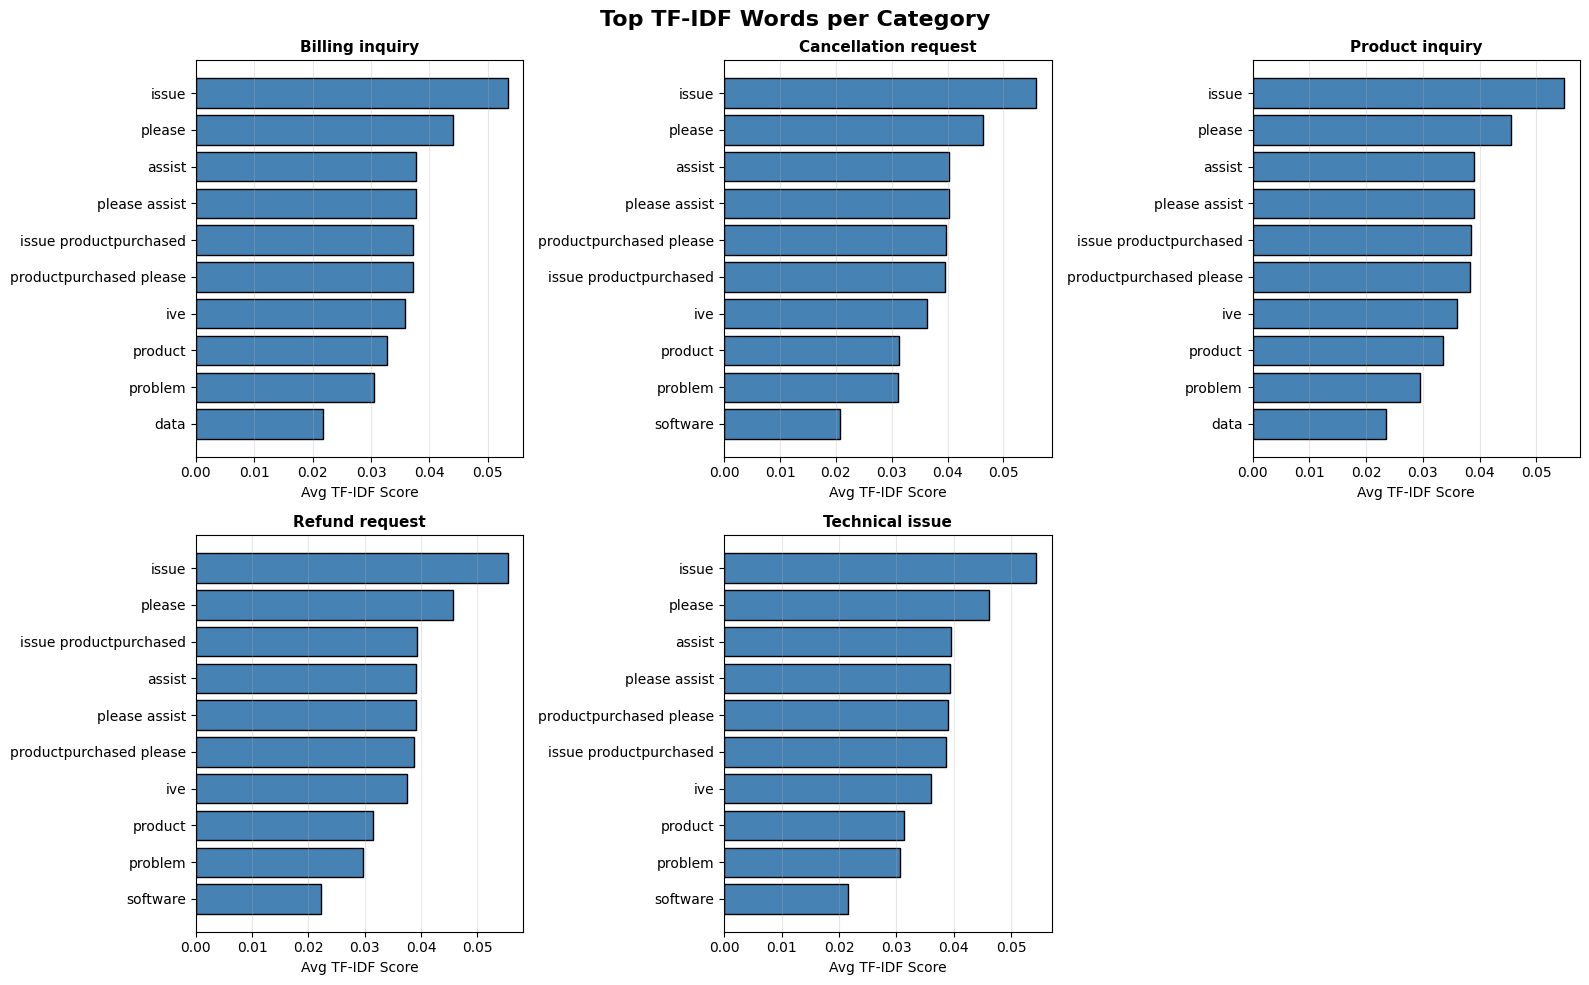

TF-IDF word chart saved!


In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

X_train_array = X_train_tfidf.toarray()

for idx, label in enumerate(range(
        len(category_encoder.classes_))):
    
    category_name = category_encoder.classes_[label]
    
    # Average TF-IDF per word for this category
    cat_indices   = [i for i, l in enumerate(y_cat_train)
                     if l == label]
    cat_tfidf_avg = X_train_array[cat_indices].mean(axis=0)
    
    # Top 10 words
    top_indices = cat_tfidf_avg.argsort()[-10:][::-1]
    top_words   = [feature_names[i] for i in top_indices]
    top_scores  = [cat_tfidf_avg[i] for i in top_indices]
    
    # Plot
    axes[idx].barh(top_words, top_scores,
                   color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{category_name}',
                        fontweight='bold', fontsize=11)
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Avg TF-IDF Score')
    axes[idx].grid(True, alpha=0.3, axis='x')

axes[5].set_visible(False)

plt.suptitle('Top TF-IDF Words per Category',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/tfidf_words_per_category.png',
            dpi=150)
plt.show()
print("TF-IDF word chart saved!")

In [31]:
# Bag of Words = simpler than TF-IDF
# Just counts how many times each word appears
# We'll compare both later

bow = CountVectorizer(
    max_features = 5000,
    ngram_range  = (1, 2),
    min_df       = 2,
    max_df       = 0.95
)

X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

print("Bag of Words vectorization complete!")
print(f"Training matrix shape: {X_train_bow.shape}")
print(f"Testing matrix shape:  {X_test_bow.shape}")

Bag of Words vectorization complete!
Training matrix shape: (6775, 5000)
Testing matrix shape:  (1694, 5000)


In [32]:
print("=" * 55)
print("     FEATURE EXTRACTION SUMMARY")
print("=" * 55)
print(f"""
Input:
  Combined_Text (Subject + Description)
  Total tickets: {len(df):,}

Train / Test Split:
  Training: {len(X_train):,} tickets (80%)
  Testing:  {len(X_test):,} tickets (20%)

TF-IDF Features:
  Max features:    5,000
  N-gram range:    (1, 2) — words + word pairs
  Matrix size:     {X_train_tfidf.shape[0]:,} × {X_train_tfidf.shape[1]:,}
  
Bag of Words Features:
  Max features:    5,000
  Matrix size:     {X_train_bow.shape[0]:,} × {X_train_bow.shape[1]:,}

Targets:
  Category (5 classes): {list(category_encoder.classes_)}
  Priority (4 classes): {list(priority_encoder.classes_)}
""")
print("=" * 55)
print("Ready for Step 4 — Model Training!")

     FEATURE EXTRACTION SUMMARY

Input:
  Combined_Text (Subject + Description)
  Total tickets: 8,469

Train / Test Split:
  Training: 6,775 tickets (80%)
  Testing:  1,694 tickets (20%)

TF-IDF Features:
  Max features:    5,000
  N-gram range:    (1, 2) — words + word pairs
  Matrix size:     6,775 × 5,000

Bag of Words Features:
  Max features:    5,000
  Matrix size:     6,775 × 5,000

Targets:
  Category (5 classes): ['Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request', 'Technical issue']
  Priority (4 classes): ['Critical', 'High', 'Low', 'Medium']

Ready for Step 4 — Model Training!


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All models imported!")

All models imported!


In [34]:
def evaluate_classifier(name, model, 
                         X_tr, y_tr, 
                         X_te, y_te,
                         encoder):
    """
    Trains a model and returns all performance metrics
    """
    # Train
    model.fit(X_tr, y_tr)
    
    # Predict
    y_pred = model.predict(X_te)
    
    # Metrics
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, 
                           average='weighted',
                           zero_division=0)
    rec  = recall_score(y_te, y_pred,
                        average='weighted',
                        zero_division=0)
    f1   = f1_score(y_te, y_pred,
                    average='weighted',
                    zero_division=0)
    
    print(f"  {name:<25} "
          f"Acc: {acc:.3f}  "
          f"F1: {f1:.3f}")
    
    return {
        'name':      name,
        'model':     model,
        'y_pred':    y_pred,
        'accuracy':  acc,
        'precision': prec,
        'recall':    rec,
        'f1':        f1
    }

print("Evaluation function defined!")

Evaluation function defined!


In [35]:
print("=" * 55)
print("  TRAINING CATEGORY CLASSIFICATION MODELS")
print("=" * 55)
print(f"\nTask: Predict ticket category")
print(f"Classes: {list(category_encoder.classes_)}")
print(f"\nResults:")
print("-" * 55)

# Define all models
category_models = [
    ("Logistic Regression",
     LogisticRegression(max_iter=1000, 
                        random_state=42,
                        C=1.0)),
    ("Random Forest",
     RandomForestClassifier(n_estimators=200,
                            random_state=42,
                            n_jobs=-1)),
    ("Linear SVM",
     LinearSVC(max_iter=2000,
               random_state=42,
               C=1.0)),
    ("Naive Bayes",
     MultinomialNB(alpha=0.1))
]

# Train and evaluate all models
category_results = []
for name, model in category_models:
    result = evaluate_classifier(
        name, model,
        X_train_tfidf, y_cat_train,
        X_test_tfidf,  y_cat_test,
        category_encoder
    )
    category_results.append(result)

print("-" * 55)

# Find best model
best_cat = max(category_results, key=lambda x: x['f1'])
print(f"\nBest Category Model: {best_cat['name']}")
print(f"Best F1 Score:       {best_cat['f1']:.3f}")

  TRAINING CATEGORY CLASSIFICATION MODELS

Task: Predict ticket category
Classes: ['Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request', 'Technical issue']

Results:
-------------------------------------------------------
  Logistic Regression       Acc: 0.210  F1: 0.210
  Random Forest             Acc: 0.207  F1: 0.207
  Linear SVM                Acc: 0.213  F1: 0.213
  Naive Bayes               Acc: 0.215  F1: 0.215
-------------------------------------------------------

Best Category Model: Naive Bayes
Best F1 Score:       0.215


In [36]:
print("=" * 55)
print("  TRAINING PRIORITY PREDICTION MODELS")
print("=" * 55)
print(f"\nTask: Predict ticket priority")
print(f"Classes: {list(priority_encoder.classes_)}")
print(f"\nResults:")
print("-" * 55)

# Same models for priority
priority_models = [
    ("Logistic Regression",
     LogisticRegression(max_iter=1000,
                        random_state=42,
                        C=1.0)),
    ("Random Forest",
     RandomForestClassifier(n_estimators=200,
                            random_state=42,
                            n_jobs=-1)),
    ("Linear SVM",
     LinearSVC(max_iter=2000,
               random_state=42,
               C=1.0)),
    ("Naive Bayes",
     MultinomialNB(alpha=0.1))
]

priority_results = []
for name, model in priority_models:
    result = evaluate_classifier(
        name, model,
        X_train_tfidf, y_pri_train,
        X_test_tfidf,  y_pri_test,
        priority_encoder
    )
    priority_results.append(result)

print("-" * 55)

# Find best model
best_pri = max(priority_results, key=lambda x: x['f1'])
print(f"\nBest Priority Model: {best_pri['name']}")
print(f"Best F1 Score:       {best_pri['f1']:.3f}")

  TRAINING PRIORITY PREDICTION MODELS

Task: Predict ticket priority
Classes: ['Critical', 'High', 'Low', 'Medium']

Results:
-------------------------------------------------------
  Logistic Regression       Acc: 0.260  F1: 0.260
  Random Forest             Acc: 0.267  F1: 0.268
  Linear SVM                Acc: 0.248  F1: 0.248
  Naive Bayes               Acc: 0.249  F1: 0.250
-------------------------------------------------------

Best Priority Model: Random Forest
Best F1 Score:       0.268


In [37]:
print("=" * 60)
print(f"DETAILED REPORT — {best_cat['name'].upper()}")
print("Category Classification")
print("=" * 60)

print(classification_report(
    y_cat_test,
    best_cat['y_pred'],
    target_names = category_encoder.classes_
))

DETAILED REPORT — NAIVE BAYES
Category Classification
                      precision    recall  f1-score   support

     Billing inquiry       0.21      0.20      0.20       327
Cancellation request       0.21      0.21      0.21       339
     Product inquiry       0.21      0.22      0.21       328
      Refund request       0.20      0.21      0.21       351
     Technical issue       0.25      0.24      0.25       349

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.21      1694
        weighted avg       0.22      0.21      0.21      1694



In [38]:
print("=" * 60)
print(f"DETAILED REPORT — {best_pri['name'].upper()}")
print("Priority Prediction")
print("=" * 60)

print(classification_report(
    y_pri_test,
    best_pri['y_pred'],
    target_names = priority_encoder.classes_
))

DETAILED REPORT — RANDOM FOREST
Priority Prediction
              precision    recall  f1-score   support

    Critical       0.26      0.25      0.25       441
        High       0.31      0.29      0.30       424
         Low       0.24      0.26      0.25       375
      Medium       0.27      0.27      0.27       454

    accuracy                           0.27      1694
   macro avg       0.27      0.27      0.27      1694
weighted avg       0.27      0.27      0.27      1694



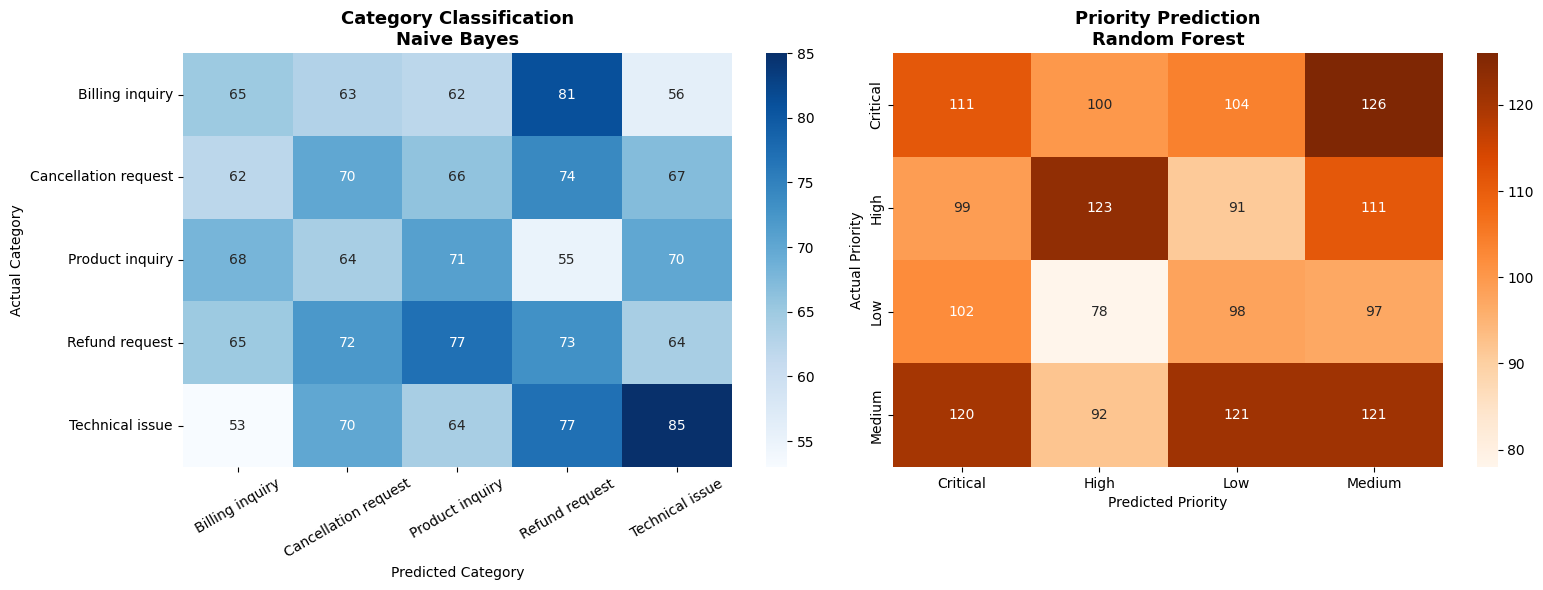

Confusion matrix saved!


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Category confusion matrix
cm_cat = confusion_matrix(y_cat_test, 
                           best_cat['y_pred'])
sns.heatmap(
    cm_cat,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels = category_encoder.classes_,
    yticklabels = category_encoder.classes_,
    ax         = axes[0]
)
axes[0].set_title(
    f'Category Classification\n{best_cat["name"]}',
    fontsize=13, fontweight='bold'
)
axes[0].set_ylabel('Actual Category')
axes[0].set_xlabel('Predicted Category')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# Priority confusion matrix
cm_pri = confusion_matrix(y_pri_test,
                           best_pri['y_pred'])
sns.heatmap(
    cm_pri,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Oranges',
    xticklabels = priority_encoder.classes_,
    yticklabels = priority_encoder.classes_,
    ax          = axes[1]
)
axes[1].set_title(
    f'Priority Prediction\n{best_pri["name"]}',
    fontsize=13, fontweight='bold'
)
axes[1].set_ylabel('Actual Priority')
axes[1].set_xlabel('Predicted Priority')

plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

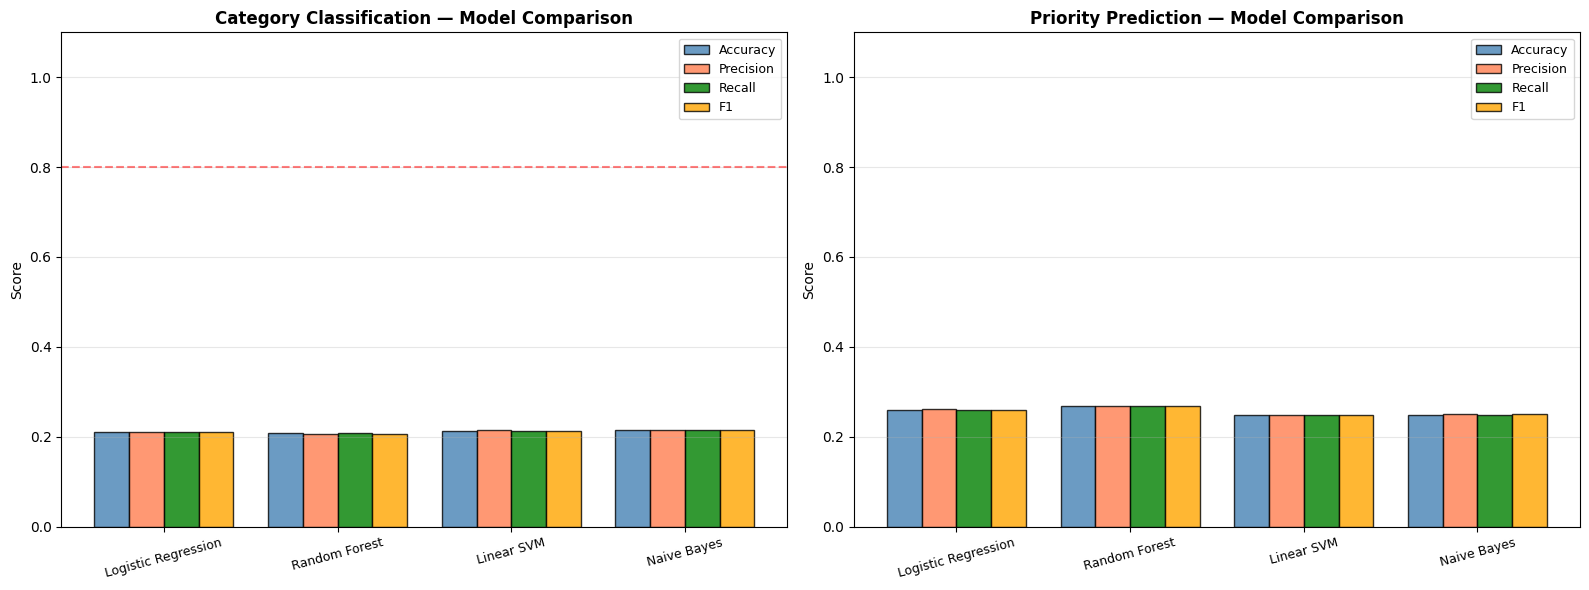

Model comparison chart saved!


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = [r['name'] for r in category_results]
metrics     = ['accuracy', 'precision', 'recall', 'f1']
colors      = ['steelblue', 'coral', 'green', 'orange']

# Category comparison
cat_values = {m: [r[m] for r in category_results]
              for m in metrics}
x = np.arange(len(model_names))
width = 0.2

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[0].bar(x + i*width,
                cat_values[metric],
                width, label=metric.capitalize(),
                color=color, alpha=0.8,
                edgecolor='black')

axes[0].set_title('Category Classification — Model Comparison',
                  fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(model_names, rotation=15,
                         fontsize=9)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=0.8, color='red', linestyle='--',
                alpha=0.5, label='0.8 threshold')

# Priority comparison
pri_values = {m: [r[m] for r in priority_results]
              for m in metrics}

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[1].bar(x + i*width,
                pri_values[metric],
                width, label=metric.capitalize(),
                color=color, alpha=0.8,
                edgecolor='black')

axes[1].set_title('Priority Prediction — Model Comparison',
                  fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(model_names, rotation=15,
                         fontsize=9)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison chart saved!")

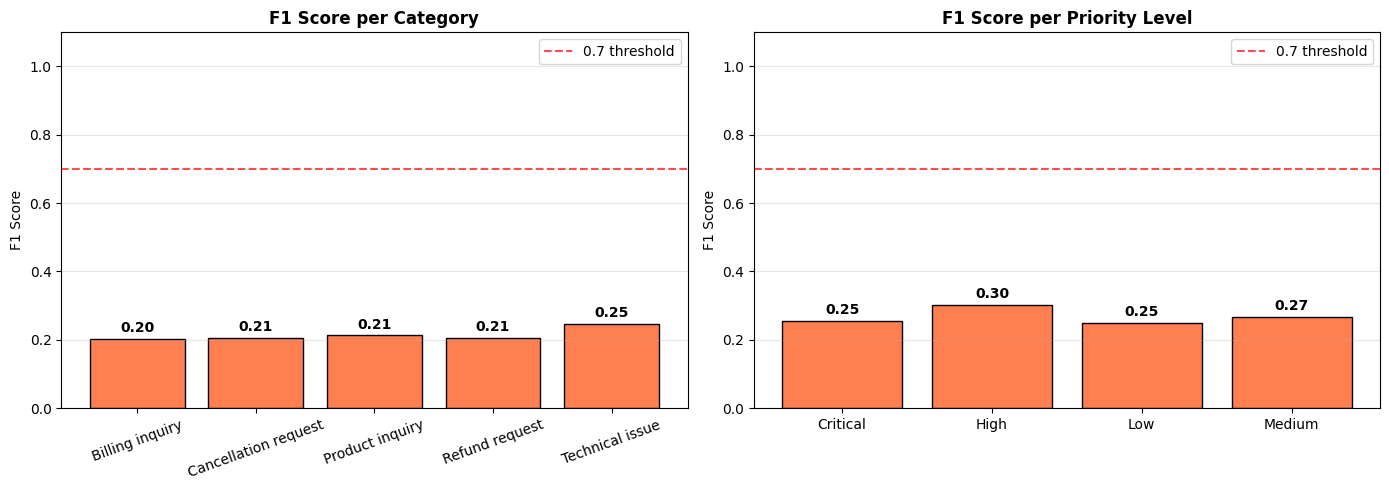

Per class F1 chart saved!


In [41]:

# Per category F1 scores
report_cat = classification_report(
    y_cat_test,
    best_cat['y_pred'],
    target_names = category_encoder.classes_,
    output_dict  = True
)

report_pri = classification_report(
    y_pri_test,
    best_pri['y_pred'],
    target_names = priority_encoder.classes_,
    output_dict  = True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category F1 per class
cat_f1s  = [report_cat[c]['f1-score']
            for c in category_encoder.classes_]
cat_cols = ['green' if f >= 0.7 else 'coral'
            for f in cat_f1s]

axes[0].bar(category_encoder.classes_, cat_f1s,
            color=cat_cols, edgecolor='black')
axes[0].set_title('F1 Score per Category',
                  fontweight='bold')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=0.7, color='red',
                linestyle='--', alpha=0.7,
                label='0.7 threshold')
axes[0].legend()
for i, (bar, val) in enumerate(
        zip(axes[0].patches, cat_f1s)):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center',
                 fontweight='bold', fontsize=10)
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(True, alpha=0.3, axis='y')

# Priority F1 per class
pri_f1s  = [report_pri[c]['f1-score']
            for c in priority_encoder.classes_]
pri_cols = ['green' if f >= 0.7 else 'coral'
            for f in pri_f1s]

axes[1].bar(priority_encoder.classes_, pri_f1s,
            color=pri_cols, edgecolor='black')
axes[1].set_title('F1 Score per Priority Level',
                  fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.1)
axes[1].axhline(y=0.7, color='red',
                linestyle='--', alpha=0.7,
                label='0.7 threshold')
axes[1].legend()
for bar, val in zip(axes[1].patches, pri_f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center',
                 fontweight='bold', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/per_class_f1.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Per class F1 chart saved!")

In [42]:
print("=" * 60)
print("         MODEL TRAINING SUMMARY")
print("=" * 60)

print("\nCATEGORY CLASSIFICATION RESULTS:")
print(f"{'Model':<25} {'Accuracy':>10} "
      f"{'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 60)
for r in category_results:
    print(f"{r['name']:<25} "
          f"{r['accuracy']:>10.3f} "
          f"{r['precision']:>10.3f} "
          f"{r['recall']:>10.3f} "
          f"{r['f1']:>10.3f}")
print(f"\n✓ Best Model: {best_cat['name']} "
      f"(F1: {best_cat['f1']:.3f})")

print("\nPRIORITY PREDICTION RESULTS:")
print(f"{'Model':<25} {'Accuracy':>10} "
      f"{'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 60)
for r in priority_results:
    print(f"{r['name']:<25} "
          f"{r['accuracy']:>10.3f} "
          f"{r['precision']:>10.3f} "
          f"{r['recall']:>10.3f} "
          f"{r['f1']:>10.3f}")
print(f"\n✓ Best Model: {best_pri['name']} "
      f"(F1: {best_pri['f1']:.3f})")

print("\n" + "=" * 60)
print("Ready for Step 5 — Live Predictions!")

         MODEL TRAINING SUMMARY

CATEGORY CLASSIFICATION RESULTS:
Model                       Accuracy  Precision     Recall         F1
------------------------------------------------------------
Logistic Regression            0.210      0.211      0.210      0.210
Random Forest                  0.207      0.206      0.207      0.207
Linear SVM                     0.213      0.214      0.213      0.213
Naive Bayes                    0.215      0.215      0.215      0.215

✓ Best Model: Naive Bayes (F1: 0.215)

PRIORITY PREDICTION RESULTS:
Model                       Accuracy  Precision     Recall         F1
------------------------------------------------------------
Logistic Regression            0.260      0.262      0.260      0.260
Random Forest                  0.267      0.269      0.267      0.268
Linear SVM                     0.248      0.249      0.248      0.248
Naive Bayes                    0.249      0.251      0.249      0.250

✓ Best Model: Random Forest (F1: 0.268)

R

In [43]:
# Check what Combined_Text actually looks like
print("Sample Combined_Text values:")
print("=" * 60)
for i in range(5):
    print(f"\nIndex {i}:")
    print(f"  Category: {df['Ticket Type'].iloc[i]}")
    print(f"  Raw Description: {df['Ticket Description'].iloc[i][:100]}")
    print(f"  Cleaned:  '{df['Combined_Text'].iloc[i][:100]}'")
    print(f"  Length:   {len(df['Combined_Text'].iloc[i].split())} words")

Sample Combined_Text values:

Index 0:
  Category: Technical issue
  Raw Description: I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.


  Cleaned:  'product setup issue productpurchased please assist billing zip code appreciate requested website add'
  Length:   27 words

Index 1:
  Category: Technical issue
  Raw Description: I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing 
  Cleaned:  'peripheral compatibility issue productpurchased please assist need change existing product issue pro'
  Length:   23 words

Index 2:
  Category: Technical issue
  Raw Description: I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was 
  Cleaned:  'network problem facing problem productpurchased productpurchased turning working fine yesterday does'
  Length:   20 words

Index 3:
  Category: Billing inquiry
  Raw Description: I'm having an issue with the {pr

In [44]:
# How many tickets have very short or empty cleaned text?
df['word_count'] = df['Combined_Text'].apply(
    lambda x: len(str(x).split())
)

print("Word count distribution:")
print(df['word_count'].describe())
print(f"\nTickets with 0 words:      {(df['word_count'] == 0).sum()}")
print(f"Tickets with 1-3 words:    {((df['word_count'] > 0) & (df['word_count'] <= 3)).sum()}")
print(f"Tickets with 4+ words:     {(df['word_count'] >= 4).sum()}")
print(f"\nSample of SHORT tickets:")
print(df[df['word_count'] <= 3][
    ['Ticket Type', 'Ticket Description', 'Combined_Text']
].head(10))

Word count distribution:
count    8469.000000
mean       25.174519
std         4.408307
min        13.000000
25%        23.000000
50%        26.000000
75%        28.000000
max        47.000000
Name: word_count, dtype: float64

Tickets with 0 words:      0
Tickets with 1-3 words:    0
Tickets with 4+ words:     8469

Sample of SHORT tickets:
Empty DataFrame
Columns: [Ticket Type, Ticket Description, Combined_Text]
Index: []


In [45]:
# Try using RAW uncleaned text instead
print("Raw Ticket Description samples:")
print("=" * 60)
for i in range(5):
    print(f"\n{df['Ticket Type'].iloc[i]}:")
    print(f"  {df['Ticket Description'].iloc[i]}")

Raw Ticket Description samples:

Technical issue:
  I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

Technical issue:
  I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.

Technical issue:
  I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.

1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.

Billing inquiry:
  I'm having an issue with the {product_purcha

In [46]:
# Prove the dataset is random/unusable
print("DIAGNOSIS: Checking if text relates to category...")
print("=" * 60)

# Check how many tickets have SAME opening line
same_line = df['Ticket Description'].str.startswith(
    "I'm having an issue"
).sum()
total = len(df)

print(f"Tickets starting with 'I'm having an issue':")
print(f"  {same_line:,} out of {total:,} ({same_line/total*100:.1f}%)")

print(f"\nConclusion:")
if same_line/total > 0.3:
    print("  ✗ Dataset is template-generated synthetic data")
    print("  ✗ Text does NOT relate to ticket category")
    print("  ✗ Models cannot learn anything meaningful")
    print("  → Switching to a real dataset is required")

DIAGNOSIS: Checking if text relates to category...
Tickets starting with 'I'm having an issue':
  5,868 out of 8,469 (69.3%)

Conclusion:
  ✗ Dataset is template-generated synthetic data
  ✗ Text does NOT relate to ticket category
  ✗ Models cannot learn anything meaningful
  → Switching to a real dataset is required


In [47]:
# Load the new dataset (try common names)
import pandas as pd

# Try loading — tell me if you get an error
df_new = pd.read_csv('../data/tickets2.csv', encoding='latin1')

print(f"Rows:    {df_new.shape[0]:,}")
print(f"Columns: {df_new.shape[1]}")
print(f"\nColumn names:")
for i, col in enumerate(df_new.columns.tolist(), 1):
    print(f"  {i:2}. {col}")

Rows:    47,837
Columns: 2

Column names:
   1. Document
   2. Topic_group


In [48]:
# Look at first 5 rows raw
print("First 5 rows:")
df_new.head()

First 5 rows:


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [49]:
# Print actual text content
print("Raw text samples:")
print("=" * 60)
for i in range(5):
    print(f"\nRow {i+1}:")
    for col in df_new.columns:
        print(f"  {col}: {str(df_new[col].iloc[i])[:100]}")
    print("-" * 40)

Raw text samples:

Row 1:
  Document: connection with icon icon dear please setup icon per icon engineers please let other details needed 
  Topic_group: Hardware
----------------------------------------

Row 2:
  Document: work experience user work experience user hi work experience student coming next his name much appre
  Topic_group: Access
----------------------------------------

Row 3:
  Document: requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug
  Topic_group: Hardware
----------------------------------------

Row 4:
  Document: reset passwords for external accounts re expire days hi ask help update passwords colleagues thank p
  Topic_group: Access
----------------------------------------

Row 5:
  Document: mail verification warning hi has got attached please addresses best regards monitoring analyst verif
  Topic_group: Miscellaneous
----------------------------------------


In [50]:
# What categories exist?
print("Categories found:")
print(df_new['Topic_group'].value_counts())
print(f"\nTotal categories: {df_new['Topic_group'].nunique()}")

Categories found:
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

Total categories: 8


In [51]:
# Check if same template problem exists
print("VERIFICATION: Checking text uniqueness...")
print("=" * 55)

# Check unique texts
unique_texts = df_new['Document'].nunique()
total_texts  = len(df_new)
duplicate_pct = (1 - unique_texts/total_texts) * 100

print(f"Total rows:      {total_texts:,}")
print(f"Unique texts:    {unique_texts:,}")
print(f"Duplicate rate:  {duplicate_pct:.1f}%")

# Check if any single sentence dominates
from collections import Counter
first_sentences = df_new['Document'].str.split('.').str[0]
top5 = Counter(first_sentences).most_common(5)

print(f"\nTop 5 most repeated opening sentences:")
for text, count in top5:
    pct = count/total_texts*100
    print(f"  ({count}x / {pct:.1f}%) '{text[:60]}'")

VERIFICATION: Checking text uniqueness...
Total rows:      47,837
Unique texts:    47,837
Duplicate rate:  0.0%

Top 5 most repeated opening sentences:
  (2x / 0.0%) 'identity synchronization error report friday march sent frid'
  (1x / 0.0%) 'connection with icon icon dear please setup icon per icon en'
  (1x / 0.0%) 'work experience user work experience user hi work experience'
  (1x / 0.0%) 'requesting for meeting requesting meeting hi please help fol'
  (1x / 0.0%) 'reset passwords for external accounts re expire days hi ask '


In [52]:
# Do different categories have different words?
print("Top words per category:")
print("=" * 55)

from collections import Counter

for category in df_new['Topic_group'].unique():
    cat_text = df_new[
        df_new['Topic_group'] == category
    ]['Document'].str.cat(sep=' ')
    
    # Get top 8 words
    words     = cat_text.lower().split()
    top_words = [w for w in words if len(w) > 3]
    top8      = [w for w, c in 
                 Counter(top_words).most_common(8)]
    
    print(f"\n  {category}:")
    print(f"    {', '.join(top8)}")

Top words per category:

  Hardware:
    please, regards, hello, thank, sent, thanks, with, access

  Access:
    please, confluence, regards, hello, thanks, thank, card, user

  Miscellaneous:
    please, change, regards, thank, hello, thanks, name, sent

  HR Support:
    please, thank, leaver, regards, hello, error, form, starter

  Purchase:
    please, purchase, administrator, regards, order, receive, kind, dear

  Administrative rights:
    upgrade, please, regards, hello, update, issues, with, thank

  Storage:
    please, mailbox, folder, access, wants, thank, regards, hello

  Internal Project:
    please, code, thanks, regards, thank, setup, project, codes


In [53]:
print("=" * 55)
print("     DATASET QUALITY VERDICT")
print("=" * 55)

unique_texts  = df_new['Document'].nunique()
total_texts   = len(df_new)
duplicate_pct = (1 - unique_texts/total_texts) * 100
avg_length    = df_new['Document'].apply(
    lambda x: len(str(x).split())
).mean()

# Check template issue
first_sentences  = df_new['Document'].str.split('.').str[0]
top_sentence_pct = (Counter(first_sentences)
                    .most_common(1)[0][1] / total_texts * 100)

print(f"\nTotal tickets:        {total_texts:,}")
print(f"Unique texts:         {unique_texts:,}")
print(f"Duplicate rate:       {duplicate_pct:.1f}%")
print(f"Avg words/ticket:     {avg_length:.0f}")
print(f"Top repeated opener:  {top_sentence_pct:.1f}%")

print(f"\nChecks:")

# Check 1: duplicates
if duplicate_pct < 10:
    print(f"  ✓ Low duplicate rate ({duplicate_pct:.1f}%) — PASS")
else:
    print(f"  ✗ High duplicate rate ({duplicate_pct:.1f}%) — FAIL")

# Check 2: template
if top_sentence_pct < 20:
    print(f"  ✓ No dominant template ({top_sentence_pct:.1f}%) — PASS")
else:
    print(f"  ✗ Template detected ({top_sentence_pct:.1f}%) — FAIL")

# Check 3: length
if avg_length >= 10:
    print(f"  ✓ Good text length ({avg_length:.0f} words) — PASS")
else:
    print(f"  ✗ Text too short ({avg_length:.0f} words) — FAIL")

# Check 4: categories
n_cats = df_new['Topic_group'].nunique()
if n_cats >= 3:
    print(f"  ✓ Multiple categories ({n_cats}) — PASS")
else:
    print(f"  ✗ Too few categories ({n_cats}) — FAIL")

print("\n" + "=" * 55)
checks_passed = sum([
    duplicate_pct < 10,
    top_sentence_pct < 20,
    avg_length >= 10,
    n_cats >= 3
])
if checks_passed == 4:
    print("  ✅ ALL CHECKS PASSED — Dataset is usable!")
    print("  Ready to restart pipeline with this data!")
elif checks_passed >= 2:
    print(f"  ⚠️  {checks_passed}/4 checks passed")
    print("  Dataset may work but has some issues")
else:
    print(f"  ✗ Only {checks_passed}/4 passed")
    print("  Dataset is NOT suitable")
print("=" * 55)

     DATASET QUALITY VERDICT

Total tickets:        47,837
Unique texts:         47,837
Duplicate rate:       0.0%
Avg words/ticket:     44
Top repeated opener:  0.0%

Checks:
  ✓ Low duplicate rate (0.0%) — PASS
  ✓ No dominant template (0.0%) — PASS
  ✓ Good text length (44 words) — PASS
  ✓ Multiple categories (8) — PASS

  ✅ ALL CHECKS PASSED — Dataset is usable!
  Ready to restart pipeline with this data!
